In [80]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pyarrow
import pickle
import json
import pwlf
import re
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [78]:
import utils.config as config
importlib.reload(config)
import utils.common as common
importlib.reload(common)
import utils.conduits as conduits
importlib.reload(conduits)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *
import scripts.openkarst.run_openkarst as ok
import utils.openkarst_network
importlib.reload(utils.openkarst_network)
importlib.reload(ok)
import utils.linear_reservoir as lr
importlib.reload(lr)
import utils.spring
importlib.reload(utils.spring)
from utils.spring import outlet_flow, write_outlet_flow, calculate_recession_coefficients
from scripts.openkarst.run_openkarst import load_network_data

In [112]:
metadata = pd.read_parquet('conduit_geometry_test/output/metadata').reset_index(drop=True)
Q = {}
def sanitize_run_id(run_id):
    return re.sub(r"[^0-9A-Za-z_-]", "_", str(run_id))
metadata_2 = metadata.copy()
metadata_2["run_id"] = metadata_2["run_id"].astype(str)

for index, row in metadata.iterrows():
    run_id_raw = row['run_id']
    run_id = sanitize_run_id(run_id_raw)
    print(run_id)
    output_dir = f'conduit_geometry_test/{row['output_dir']}'
    network_name = row['network_name']
    if network_name == 'pykasso_n58_low_slope':
        network_dir = 'conduit_geometry_test/networks/pykasso_n58/low_slope'
    else:
        network_dir = f'conduit_geometry_test/networks/{network_name}'
    network = load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv')
    results = np.load(f'{output_dir}/results_arrays.npz')
    Q = results['Q']
    y = results['y']
    t = results['t']
    spring = outlet_flow(network, Q)
    write_outlet_flow(t, spring,f'conduit_geometry_test/output/hydrographs_df', run_id = run_id, method = 'dataframe')
    print(index)
    metadata_2.loc[index, 'run_id'] = run_id

2026-05-07_00_45_24_1_0
0
2026-05-07_00_45_24_2_0
1
2026-05-07_00_45_24_3_0
2
2026-05-07_00_45_24_4_0
3
2026-05-07_00_45_24_6_0
4


In [114]:
Q = {}
for run_id in metadata_2['run_id']:
    print(run_id)
    network_name = metadata_2[metadata_2['run_id'] == run_id]['network_name'].values[0]
    Q[network_name] = pd.read_csv(f'conduit_geometry_test/output/hydrographs_df/{run_id}.csv')

2026-05-07_00_45_24_1_0
2026-05-07_00_45_24_2_0
2026-05-07_00_45_24_3_0
2026-05-07_00_45_24_4_0
2026-05-07_00_45_24_6_0


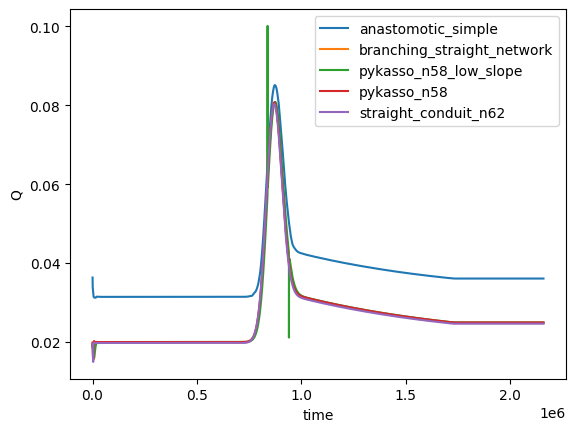

In [117]:
for name, spring in Q.items():
    sns.lineplot(x=spring['time'], y=spring['Q'], label=name)